In [5]:
# import packages
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# create dataframe with housing info and verify data import
df = pd.read_csv("D600 Task 2 Dataset 1 Housing Information.csv")
df

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,4922,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,...,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,5009,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,...,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,4450,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,...,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,1070,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,...,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,400,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,...,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,6987,307821.1758,550.00,2.111022,4,892.35,11.89,7.97,28.18,19.23,...,4.76,3.81,6.87,No,White,Yes,1,18,241131.63070,1
6996,6995,421368.8869,1726.12,4.056115,2,943.19,34.06,5.82,90.45,17.60,...,5.31,9.84,10.00,No,White,Yes,1,18,481604.80730,1
6997,6996,473382.5348,1026.36,2.077177,5,149.31,0.10,8.81,31.79,11.59,...,4.98,7.47,2.96,No,Green,No,1,13,380555.49390,1
6998,6998,343397.9756,2218.22,1.000000,4,526.81,11.18,9.20,15.21,3.96,...,4.68,7.66,6.12,No,Blue,Yes,1,10,442610.31710,0


In [7]:
# slice the required columns for analysis into new dataframe
newdf = df[['SquareFootage', 'NumBedrooms', 'IsLuxury']].copy()
newdf

,SquareFootage,NumBedrooms,IsLuxury
0,566.62,4,0
1,1472.34,2,0
2,550.00,3,0
3,941.81,2,0
4,550.00,3,0
...,...,...,...
6995,550.00,4,1
6996,1726.12,2,1
6997,1026.36,5,1
6998,2218.22,4,0


In [8]:
# create frequency table of the dependent variable, isluxury
luxury_count = newdf['IsLuxury'].value_counts()
luxury_count

IsLuxury
1    3528
0    3472
Name: count, dtype: int64

In [9]:
# describe the independent variable, squarefootage
newdf['SquareFootage'].describe()

count    7000.000000
mean     1048.947459
std       426.010482
min       550.000000
25%       660.815000
50%       996.320000
75%      1342.292500
max      2874.700000
Name: SquareFootage, dtype: float64

In [10]:
# describe the independent variable, numbedrooms
newdf['NumBedrooms'].describe()

count    7000.000000
mean        3.008571
std         1.021940
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         7.000000
Name: NumBedrooms, dtype: float64

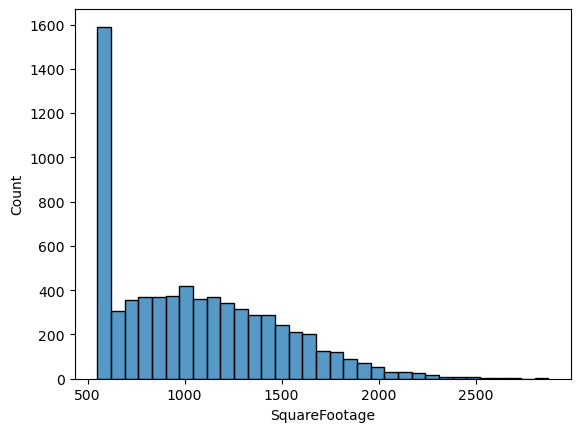

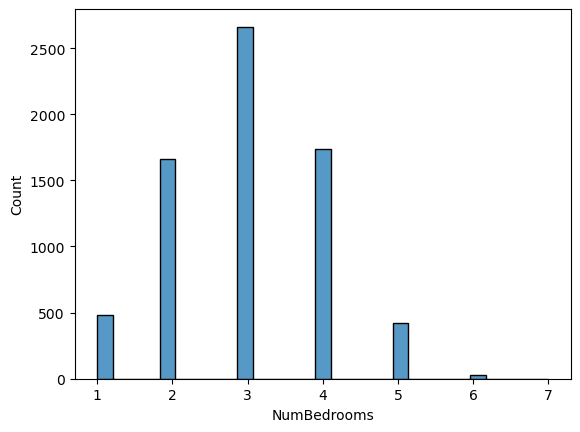

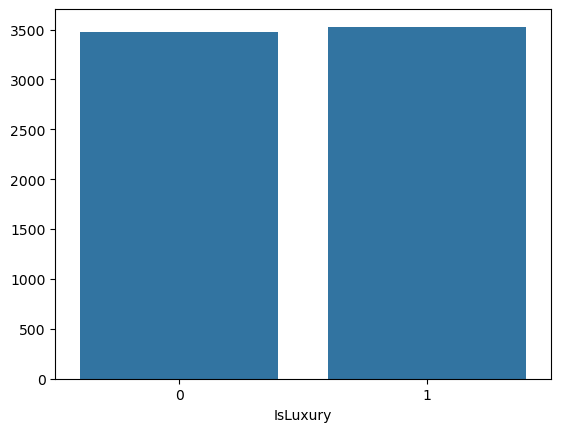

In [11]:
# create univariate visualizations of the variables
sns.histplot(newdf['SquareFootage'])
plt.show()
sns.histplot(newdf['NumBedrooms'])
plt.show()
sns.barplot(x = luxury_count.index, y = luxury_count.values)
plt.show()

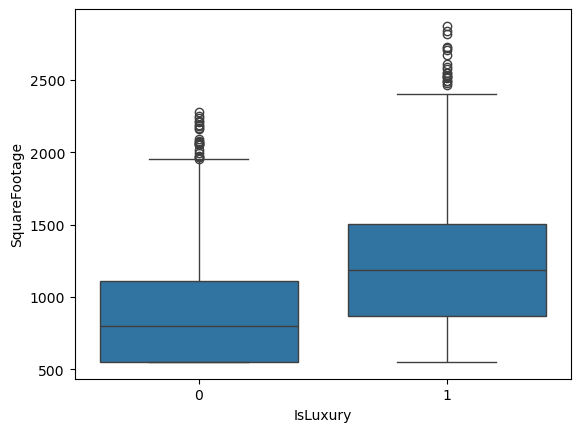

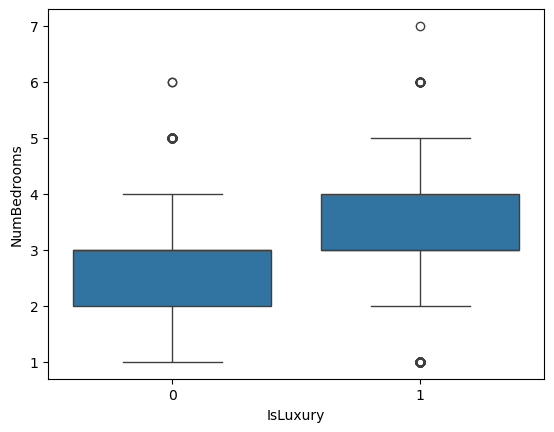

In [12]:
# create bivariate visualizations of the variables
sns.boxplot(x = 'IsLuxury', y = 'SquareFootage', data = newdf)
plt.show()
sns.boxplot(x = 'IsLuxury', y = 'NumBedrooms', data = newdf)
plt.show()

In [13]:
# define the independent variables SquareFootage and NumBedrooms
X = newdf[['SquareFootage', 'NumBedrooms']]

# define the dependent variable IsLuxury
y = newdf['IsLuxury']

# split the data 80/20 for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# add constants for statsmodels
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# combine X and y for training and testing sets
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

# Export to CSV
train_df.to_csv('Training Data.csv', index=False)
test_df.to_csv('Testing Data.csv', index=False)

In [14]:
# fit to logistic regression and print summary
logit_model = sm.Logit(y_train, X_train).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.574255
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               IsLuxury   No. Observations:                 5600
Model:                          Logit   Df Residuals:                     5597
Method:                           MLE   Df Model:                            2
Date:                Mon, 24 Mar 2025   Pseudo R-squ.:                  0.1714
Time:                        20:31:50   Log-Likelihood:                -3215.8
converged:                       True   LL-Null:                       -3881.2
Covariance Type:            nonrobust   LLR p-value:                1.092e-289
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.1645      0.138    -30.140      0.000      -4.435      -3.894
SquareFootage     0.

In [15]:
# create backward elimination function for optimization
def backward_elimination(X, y, sl = 0.05):
    cols = X.columns.tolist()
    while len(cols) > 1:
        logit_model = sm.Logit(y, X[cols]).fit(disp = 0)
        pvalues = logit_model.pvalues[1:]
        max_pvalue = pvalues.max()
        if max_pvalue > sl:
            removed_feature = pvalues.idxmax()
            cols.remove(removed_feature)
        else:
            break
    return X[cols]

# perform the backward elimination on the training data
X_train_optimized = backward_elimination(X_train, y_train)
X_test_optimized = X_test[X_train_optimized.columns[1:]]
X_test_optimized = sm.add_constant(X_test_optimized)

# fit and print the optimized model
logit_model_optimized = sm.Logit(y_train, X_train_optimized).fit()
print(logit_model_optimized.summary())

Optimization terminated successfully.
         Current function value: 0.574255
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               IsLuxury   No. Observations:                 5600
Model:                          Logit   Df Residuals:                     5597
Method:                           MLE   Df Model:                            2
Date:                Mon, 24 Mar 2025   Pseudo R-squ.:                  0.1714
Time:                        20:31:50   Log-Likelihood:                -3215.8
converged:                       True   LL-Null:                       -3881.2
Covariance Type:            nonrobust   LLR p-value:                1.092e-289
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.1645      0.138    -30.140      0.000      -4.435      -3.894
SquareFootage     0.

In [16]:
# use the optimized model to make predictions on the training set
pred_prob_train = logit_model_optimized.predict(X_train_optimized)
pred_train = (pred_prob_train > 0.5).astype(int)

# calculate confusion matrix
conf_matrix_train = confusion_matrix(y_train, pred_train)
print(conf_matrix_train)

# calculate accuracy
acc_train = accuracy_score(y_train, pred_train)
print(acc_train)

[[2010  755]
 [ 837 1998]]
0.7157142857142857


In [17]:
# use the optimized model to make predictions on the test set
pred_prob_test = logit_model_optimized.predict(X_test_optimized)
pred_test = (pred_prob_test > 0.5).astype(int)

# calculate confusion matrix
conf_matrix_test = confusion_matrix(y_test, pred_test)
print(conf_matrix_test)

# calculate accuracy
acc_test = accuracy_score(y_test, pred_test)
print(acc_test)

[[522 185]
 [208 485]]
0.7192857142857143


In [18]:
# test for multicollinearity with variance inflation factor
mc = newdf[['SquareFootage', 'NumBedrooms']]
mc = sm.add_constant(mc)
vif = pd.DataFrame()
vif['variable'] = mc.columns
vif['vif'] = [variance_inflation_factor(mc.values, i) for i in range(mc.shape[1])]
print(vif)

        variable        vif
0          const  14.564638
1  SquareFootage   1.007749
2    NumBedrooms   1.007749


In [42]:
# check for duplicate rows by creating a new dataframe from the data provided
df = pd.read_csv("D600 Task 2 Dataset 1 Housing Information.csv")
dup = df.duplicated().sum()
print(dup)

0
